In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

DRIVE_DIRECTORY = Path.cwd().parent / "data"

In [2]:
colunas = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num",
]

In [3]:
df_cleveland = pd.read_csv(
    os.path.join(DRIVE_DIRECTORY, "processed.cleveland.data"),
    names=colunas,
    na_values="?",
)
df_cleveland.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
df_cleveland.shape

(303, 14)

In [5]:
df_cleveland.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [6]:
df_cleveland.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [7]:
df_cleveland[df_cleveland["ca"].isnull()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [8]:
df_cleveland.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [9]:
df_limpo = df_cleveland.copy()
df_limpo['ca'] = df_limpo['ca'].fillna(df_limpo['ca'].mode()[0])
df_limpo['thal'] = df_limpo['thal'].fillna(df_limpo['thal'].mode()[0])
df_limpo.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [10]:
df_limpo.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [11]:
colunas_float = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'slope', 'ca', 'thal', 'num']
for i in colunas_float:
    df_limpo[i] = df_limpo[i].astype(int)

In [12]:
df_limpo['num'] = df_limpo['num'].apply(lambda x: 1 if x >= 1 else 0)
df_limpo.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [13]:
df_limpo

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0,7,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2,7,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1,7,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1,3,1


## Remover/Tratar Outliers

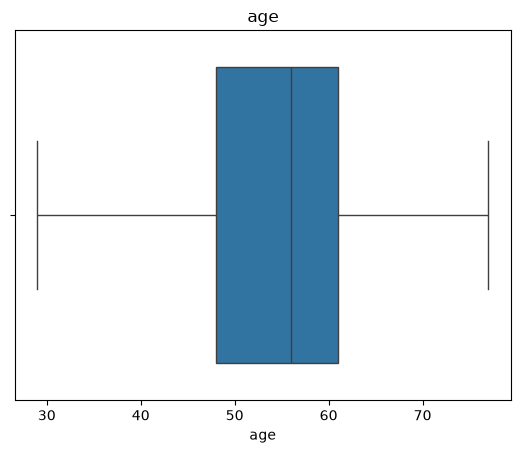

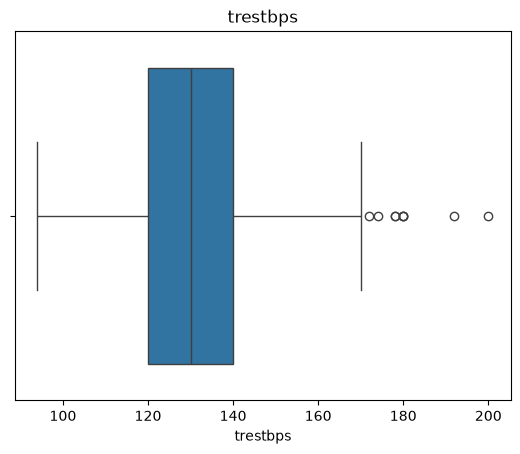

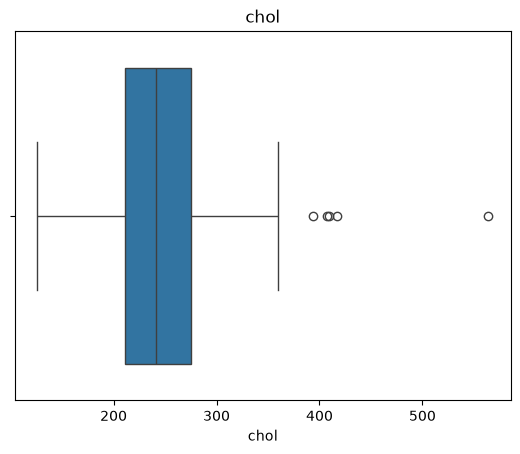

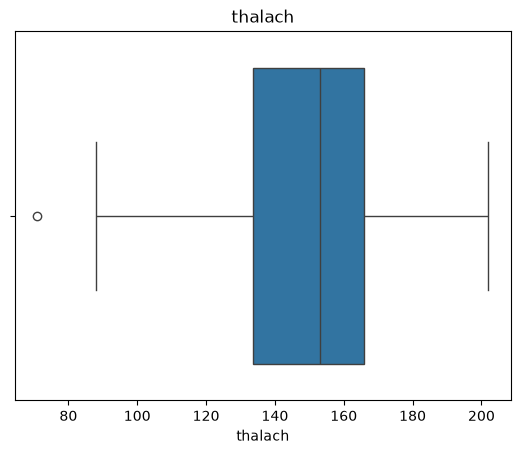

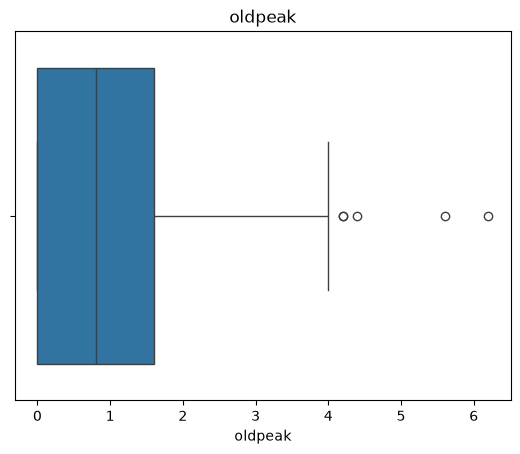

In [14]:
variaveis = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for variavel in variaveis:
    sns.boxplot(data=df_limpo, x=df_limpo[variavel]);
    plt.title(variavel)
    plt.show()

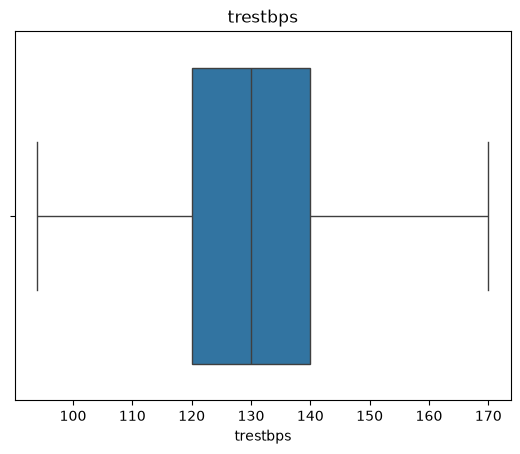

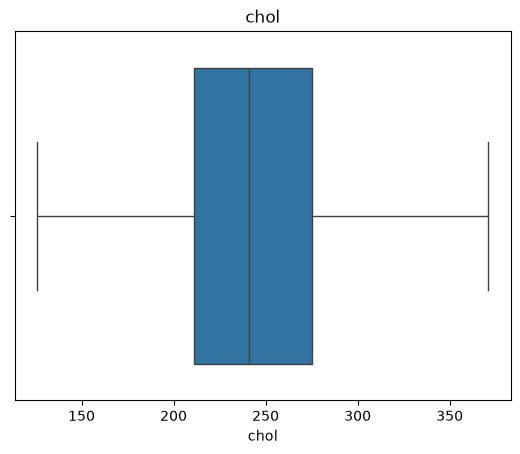

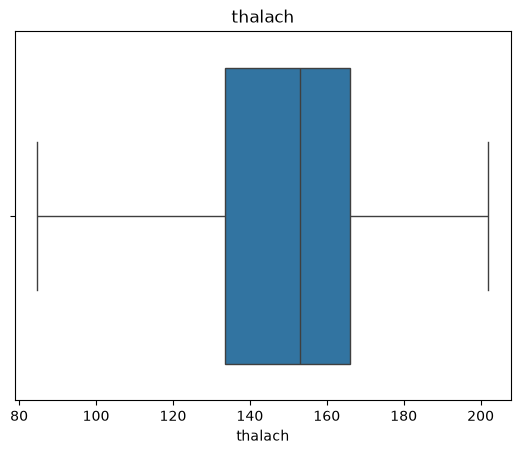

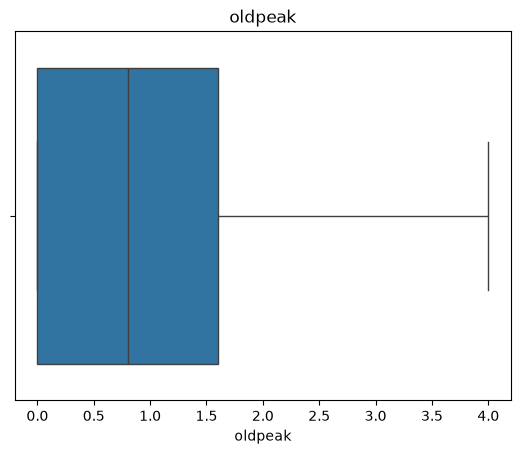

In [15]:
variaveis = ['trestbps', 'chol', 'thalach', 'oldpeak']
for variavel in variaveis:
    valor_chao_caixa = df_limpo[variavel].quantile(0.25)
    valor_teto_caixa = df_limpo[variavel].quantile(0.75)

    altura_da_caixa = valor_teto_caixa - valor_chao_caixa
    distancia_segura = altura_da_caixa * 1.5

    limite_inferior = valor_chao_caixa - distancia_segura
    limite_superior = valor_teto_caixa + distancia_segura

    df_limpo[variavel] = df_limpo[variavel].clip(limite_inferior, limite_superior)

    sns.boxplot(data=df_limpo, x=df_limpo[variavel]);
    plt.title(variavel)
    plt.show()



## Visualização de Dados

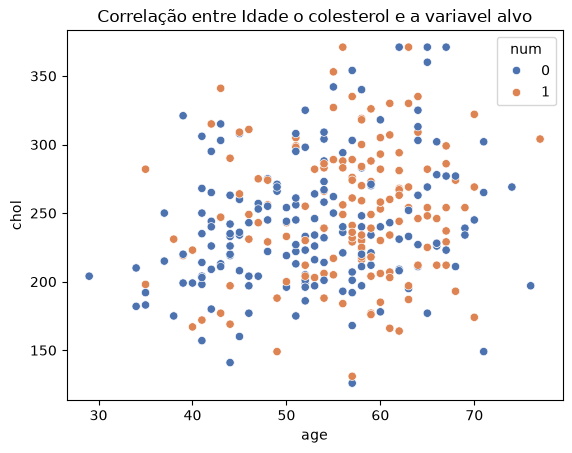

In [16]:
sns.scatterplot(
    df_limpo,
    x=df_limpo['age'],
    y=df_limpo['chol'],
    hue=df_limpo['num'],
    palette='deep'
)
plt.title("Correlação entre Idade o colesterol e a variavel alvo")
plt.show()

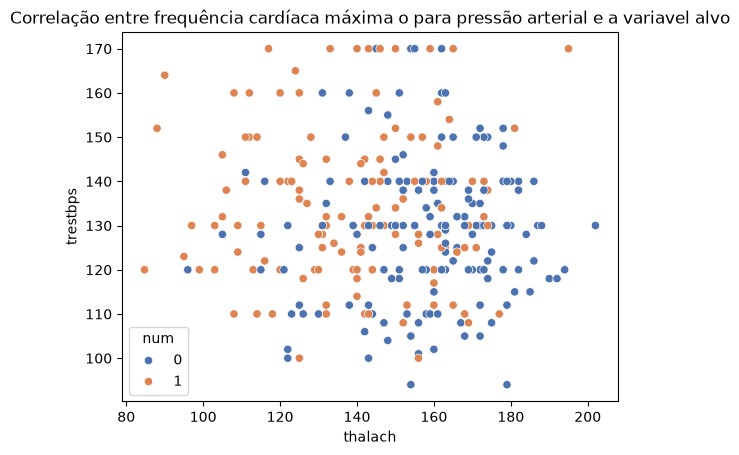

In [17]:
sns.scatterplot(
    df_limpo,
    x=df_limpo['thalach'],
    y=df_limpo['trestbps'],
    hue=df_limpo['num'],
    palette='deep'
)
plt.title("Correlação entre frequência cardíaca máxima o para pressão arterial e a variavel alvo")
plt.show()

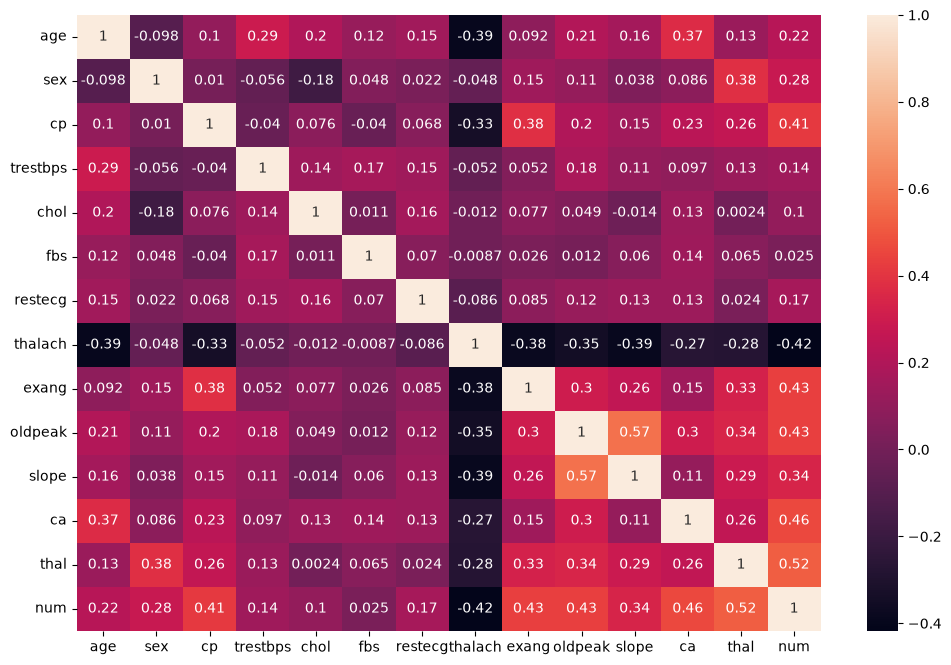

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df_limpo.corr(), annot=True);

## Padronização dos dados

In [19]:
scaler = StandardScaler()
colunas_para_escalar = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df_limpo[colunas_para_escalar] = scaler.fit_transform(df_limpo[colunas_para_escalar])
df_limpo.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0.948726,1,1,0.821446,-0.265040,1,2,0.015306,0,1.150938,3,0,6,0
1,1.392002,1,4,1.723905,0.851214,0,2,-1.835388,1,0.429108,2,3,3,1
2,1.392002,1,4,-0.682652,-0.349285,0,2,-0.910041,1,1.421625,2,2,7,1
3,-1.932564,1,3,-0.081013,0.093004,0,0,1.645679,0,2.233684,3,0,3,0
4,-1.489288,0,2,-0.081013,-0.875820,0,2,0.984717,0,0.338879,1,0,3,0


In [20]:
one_hot_code = ['thal', 'restecg', 'cp']
data = pd.get_dummies(
    df_limpo, prefix=one_hot_code, columns=one_hot_code, dtype=float,
    drop_first=True
)
data

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,num,thal_6,thal_7,restecg_1,restecg_2,cp_2,cp_3,cp_4
0,0.948726,1,0.821446,-0.265040,1,0.015306,0,1.150938,3,0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.392002,1,1.723905,0.851214,0,-1.835388,1,0.429108,2,3,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.392002,1,-0.682652,-0.349285,0,-0.910041,1,1.421625,2,2,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,-1.932564,1,-0.081013,0.093004,0,1.645679,0,2.233684,3,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.489288,0,-0.081013,-0.875820,0,0.984717,0,0.338879,1,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,1,-1.284292,0.387863,0,-0.777848,0,0.158422,2,0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
299,1.502821,1,0.761282,-1.107495,1,-0.381271,0,2.143455,2,2,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
300,0.283813,1,-0.081013,-2.413301,0,-1.526939,1,0.158422,2,1,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
301,0.283813,0,-0.081013,-0.201856,0,1.072845,0,-0.924324,2,1,1,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [21]:
data.to_csv(os.path.join(DRIVE_DIRECTORY, "df_cleveland_limpo.csv"), index=False)